In [112]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa

pd.options.future.infer_string = False
pd.options.mode.string_storage = "python"


# Capacity factor year can be chosen to be different
capacity_factor_year = 2017

def hourly_climatology(df):
    df = df[~((df.utc_time.dt.month == 2) & (df.utc_time.dt.day == 29))]
    df["month"] = df["utc_time"].dt.month
    df["day"] = df["utc_time"].dt.day
    df["hour"] = df["utc_time"].dt.hour
    
    result = (
        df.groupby(["month","day","hour"])["cf"]
        .mean()
        .reset_index()
    )
    result["timestamp"] = pd.to_datetime(dict(year=2017, month=result["month"], day=result["day"], hour=result["hour"]))

    result = result.sort_values("timestamp").reset_index(drop=True)

    # Create formatted column
    result["datetime"] = result["timestamp"].dt.strftime("%d/%m %H:%M")

    return result


def load_base_year_data(cf_year):
    """
    If cf_year = None then use 10 year average capacity factor data
    If cf_year is given then show the actual year
    """
    demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)
    if cf_year is None:
        offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)
        demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)

        pv = pv_cf.rename(columns={"cf": "pv_cf"})
        onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
        offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

        work_df = pd.concat([pv, onshore, offshore, demand], axis=1)
        work_df.index = pd.to_datetime(
            "2015/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
    else:

        offshore_wind_cf_df = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
        onshore_wind_cf_df = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
        pv_cf_df = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")

        # Convert ISO8601 to datetime
        offshore_wind_cf_df["utc_time"] = pd.to_datetime(offshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        onshore_wind_cf_df["utc_time"] = pd.to_datetime(onshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        pv_cf_df["utc_time"] = pd.to_datetime(pv_cf_df["utc_time"], utc=True, errors="raise")

        # Keep only time and Denmark
        df_pv = pv_cf_df[["utc_time", "DNK"]]
        df_onshore_wind = onshore_wind_cf_df[["utc_time", "DNK"]]
        df_offshore_wind = offshore_wind_cf_df[["utc_time", "DNK"]]

        # Filter out the exact year
        df_pv = df_pv[df_pv["utc_time"].dt.year == cf_year]
        df_onshore_wind = df_onshore_wind[df_onshore_wind["utc_time"].dt.year == cf_year]
        df_offshore_wind = df_offshore_wind[df_offshore_wind["utc_time"].dt.year == cf_year]

        # Rename columns
        df_pv = df_pv.rename(columns={"DNK": "cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"DNK": "cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"DNK": "cf"})
        
        # Remove year from capacity factor dataframes
        df_pv = hourly_climatology(df_pv)
        df_onshore_wind = hourly_climatology(df_onshore_wind)
        df_offshore_wind = hourly_climatology(df_offshore_wind)

        df_pv = df_pv[["datetime", "cf"]]
        df_onshore_wind = df_onshore_wind[["datetime", "cf"]]
        df_offshore_wind = df_offshore_wind[["datetime", "cf"]]

        # Rename columns
        df_pv = df_pv.rename(columns={"cf": "pv_cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"cf": "onshore_cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"cf": "offshore_cf"})

        # Set index
        df_pv = df_pv.set_index("datetime")
        df_onshore_wind = df_onshore_wind.set_index("datetime")
        df_offshore_wind = df_offshore_wind.set_index("datetime")

        # Concat the dataframes
        work_df = pd.concat([df_pv, df_onshore_wind, df_offshore_wind, demand], axis=1)
        work_df.index = pd.to_datetime(
            str(cf_year) + "/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
        
work_df = load_base_year_data(capacity_factor_year)
work_df.index = pd.DatetimeIndex(
    pd.to_datetime(work_df.index, format="%d/%m/%Y %H:%M")
)


In [113]:
# Technology lifetimes
onshore_wind_lifetime = 30 # years
offshore_wind_lifetime = 30 # years
pv_lifetime = 35 # years
ccgt_lifetime = 25 # years
ocgt_lifetime = 25 # years
biomass_chp_lifetime = 25 # years
coal_lifetime = 45 # years
oil_lifetime = 32 # years

# CAPEX
onshore_wind_capex = 1160000 # EUR/MW
offshore_wind_capex = 2500000 # EUR/MW
pv_capex = 500000 # EUR/MW
ccgt_capex = 900000 # EUR/MW
ocgt_capex = 600000 # EUR/MW
biomass_chp_capex = 5000000 # EUR/MW
coal_capex = 2750000 # EUR/MW
oil_capex = 900000 # EUR/MW

# Annualised capital costs
annualised_offshore_wind_capex = offshore_wind_capex / offshore_wind_lifetime # EUR/MW/year
annualised_onshore_wind_capex = onshore_wind_capex / onshore_wind_lifetime # EUR/MW/year
annualised_pv_capex = pv_capex / pv_lifetime # EUR/MW/year
annualised_ccgt_capex = ccgt_capex / ccgt_lifetime # EUR/MW/year
annualised_ocgt_capex = ocgt_capex / ocgt_lifetime # EUR/MW/year
annualised_chp_capex = biomass_chp_capex / biomass_chp_lifetime # EUR/MW/year
annualised_coal_capex = coal_capex / coal_lifetime # EUR/MW/year
annualised_oil_capex = oil_capex / oil_lifetime # EUR/MW/year


# Annual OPEX costs
offshore_wind_opex = 40000 # EUR/MW/year
onshore_wind_opex = 17000 # EUR/MW/year
pv_opex = 10500 # EUR/MW/year
ccgt_opex = 30500 # EUR/MW/year
ocgt_opex = 20000 # EUR/MW/year
chp_opex = 150000 # EUR/MW/year
coal_opex = 45 * 1000 # EUR/MW/year
oil_opex = 35 * 1000 # EUR/MW/year

# Efficiencies of generators
ccgt_efficiency = 0.57
ocgt_efficiency = 0.4
chp_efficiency = 0.25
coal_efficiency = 0.38
oil_efficiency = 0.3

# Input costs
gas_price = 30 # €/MWh
chp_input_price = 25 # €/MWh
coal_fuel_price = 27.5 # €/MWh
oil_fuel_price = 95 # €/MWh

# Setting up marginal generation costs
onshore_wind_marginal_cost = 4 # EUR/MWh
offshore_wind_marginal_cost = 2 # EUR/MWh
pv_marginal_cost = 0 # EUR/MWh
ccgt_marginal_cost = 4.5 + gas_price / ccgt_efficiency # EUR/MWh
ocgt_marginal_cost =  4.5 + gas_price / ocgt_efficiency # EUR/MWh
chp_marginal_cost = 15 + chp_input_price / chp_efficiency # EUR/MWh
coal_marginal_cost = 4 + coal_fuel_price / coal_efficiency # EUR/MWh
oil_marginal_cost = 5 + oil_fuel_price / oil_efficiency # EUR/MWh



# PyPsa setup


In [114]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)

n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

n.add(
    "Carrier",
    "Coal",
    co2_emissions=0,
    nice_name="Coal"
)

n.add(
    "Carrier",
    "Oil",
    co2_emissions=0,
    nice_name="Oil"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_nom=2650,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_nom=4860,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex+ onshore_wind_opex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_nom=4800,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex + pv_opex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom=2000,
    p_nom_extendable=True,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex + chp_opex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    p_nom=1750,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex + ccgt_opex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex + ocgt_opex),
)

n.add(
    "Generator",
    "DKCoal",
    bus="DK",
    carrier="Coal",
    p_nom_extendable=True,
    p_nom=650,
    marginal_cost=coal_marginal_cost,
    capital_cost=annualised_coal_capex + coal_opex,
)

n.add(
    "Generator",
    "DKOil",
    bus="DK",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=300,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex,
)

In [115]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT,DKCoal,DKOil
bus,DK,DK,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT,Coal,Oil
p_nom,2650.0,4860.0,4800.0,2000.0,1750.0,750.0,650.0,300.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,123333.333333,55666.666667,24785.714286,350000.0,66500.0,44000.0,106111.111111,63125.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5,76.368421,321.666667


In [116]:
# Solver
n.optimize(solver_name="highs")
#n.statistics()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 181.81it/s]
INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70089 primals, 148928 duals
Objective: 3.89e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

## Winter week

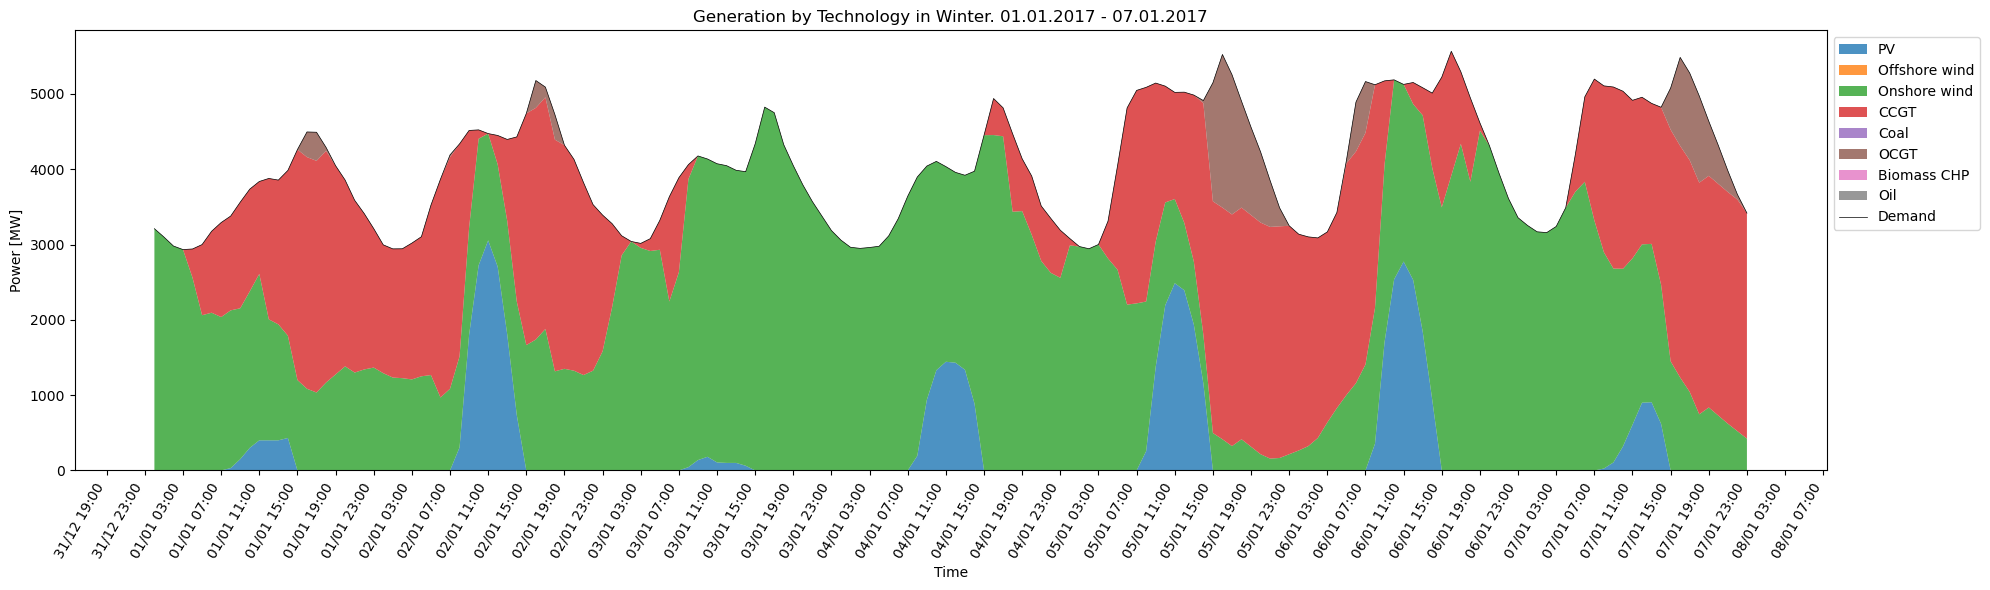

In [117]:
# Date range winter week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-07 23:00:00")

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost per technology
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech → take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# Ensure datetime index
dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]

ax.stackplot(x, y, labels=dispatch_plot.columns, alpha=0.8)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.5,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
    f"Generation by Technology in Winter. "
    f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
else:
    ax.set_title("Generation by Technology in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Summer week

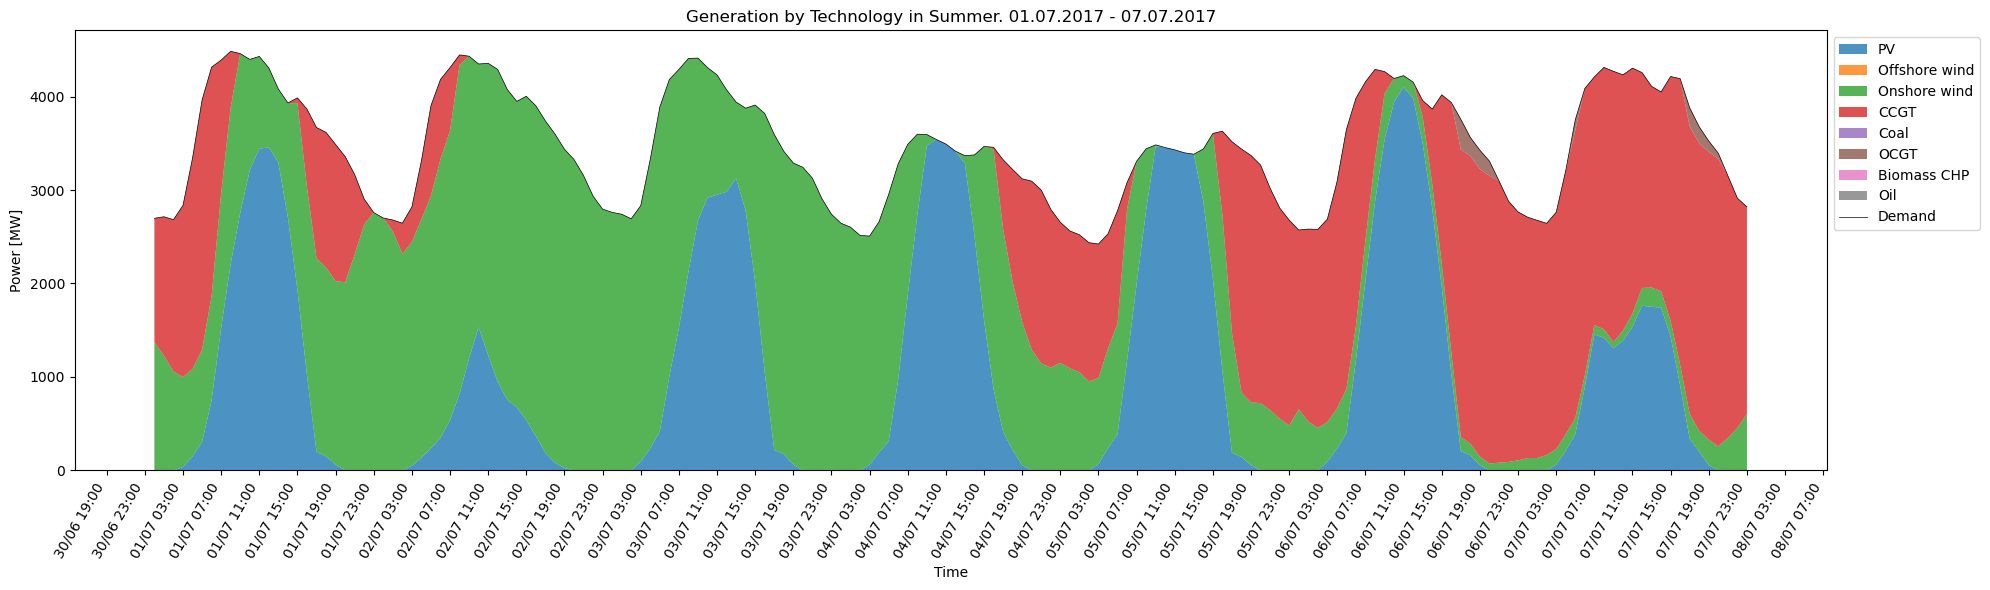

In [118]:
# Date range summer week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-07 23:00:00")

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost per technology
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech +> take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# Ensure datetime index
dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]

ax.stackplot(x, y, labels=dispatch_plot.columns, alpha=0.8)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.5,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
    f"Generation by Technology in Summer. "
    f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
else:
    ax.set_title("Generation by Technology in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [119]:
capacity = n.generators[["carrier", "p_nom_opt"]].copy()

# Map to nice names
capacity["Technology"] = capacity["carrier"].map(n.carriers.nice_name)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")
print(capacity_table)

Year used for simulation: 2017
Technology
Onshore wind     8279.8
PV               6248.5
CCGT             3076.9
OCGT             2244.5
Coal                0.0
Biomass CHP         0.0
Oil                 0.0
Offshore wind       0.0
Name: p_nom_opt, dtype: float64


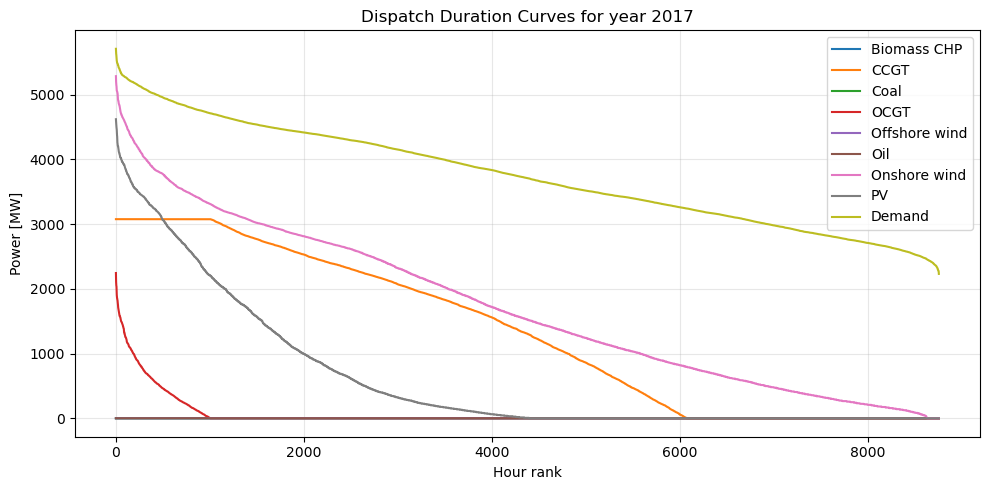

In [120]:
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

dispatch_nice["Demand"] = work_df["demand_mw"]

duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

fig, ax = plt.subplots(figsize=(10, 5))

duration_df.plot(ax=ax)

ax.set_title(f"Dispatch Duration Curves for year {capacity_factor_year}")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Annual Electricity Mix

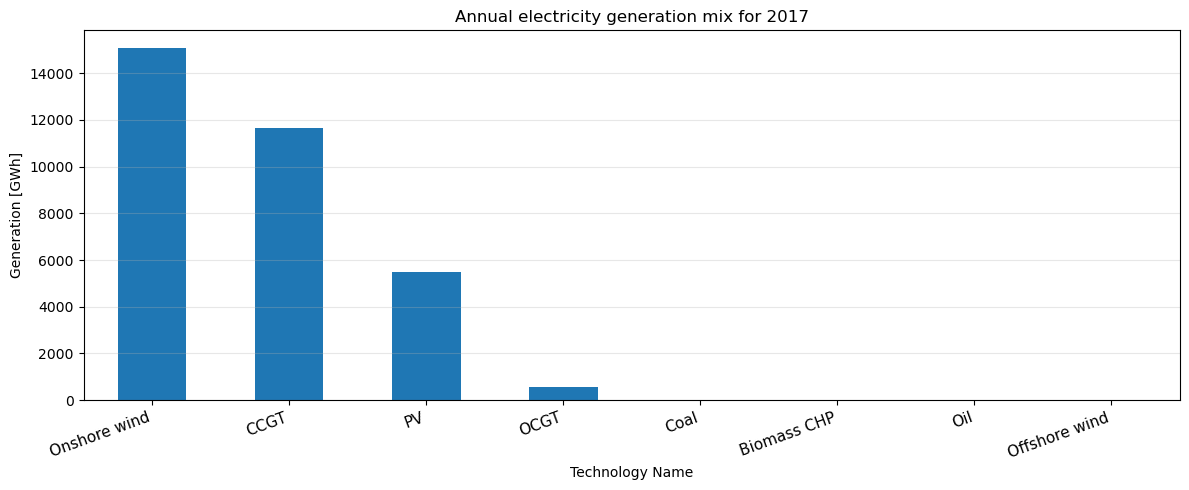

In [121]:
# Annual generation by technology [MWh]
annual_generation = dispatch_nice.drop(columns="Demand", errors="ignore").sum(axis=0)

annual_generation_df = annual_generation.to_frame(name="generation_mwh")
annual_generation_df["generation_gwh"] = annual_generation_df["generation_mwh"] / 1000

annual_generation_df["share"] = (
    annual_generation_df["generation_mwh"] /
    annual_generation_df["generation_mwh"].sum()
)

annual_generation_df["share_percent"] = 100 * annual_generation_df["share"]

annual_generation_df.sort_values("generation_mwh", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))  # wider figure

annual_generation_df["generation_gwh"] \
    .sort_values(ascending=False) \
    .plot.bar(ax=ax)

# Labels and title
ax.set_ylabel("Generation [GWh]")
ax.set_xlabel("Technology Name")  # X label added
ax.set_title(f"Annual electricity generation mix for {capacity_factor_year}")

# Rotate x labels and increase font size
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)

# Grid
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# PART B

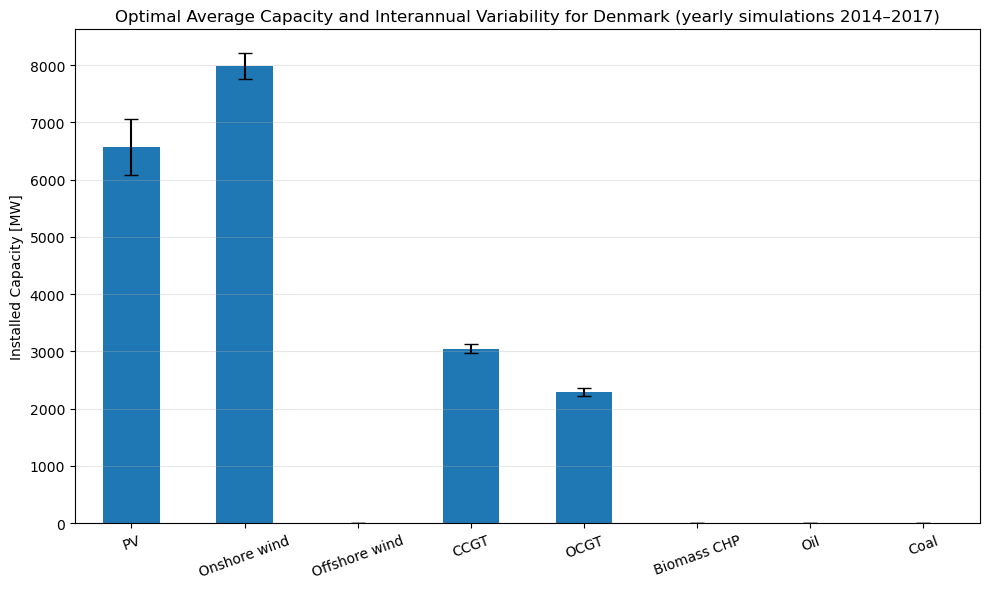

In [122]:
# Results from simulation

capacity_by_year = pd.DataFrame({
    2014: {
        "PV": 6508.6,
        "Onshore wind": 8025.9,
        "Offshore wind": 0.0,
        "CCGT": 2967.4,
        "OCGT": 2229.5,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    },
    2015: {
        "PV": 6236.6,
        "Onshore wind": 7897.1,
        "Offshore wind": 0.0,
        "CCGT": 3012.6,
        "OCGT": 2380.4,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    },
    2016: {
        "PV": 7271.3,
        "Onshore wind": 7744.9,
        "Offshore wind": 0.0,
        "CCGT": 3137.5,
        "OCGT": 2315.1,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    },
    2017: {
        "PV": 6248.5,
        "Onshore wind": 8279.8,
        "Offshore wind": 0.0,
        "CCGT": 3076.9,
        "OCGT": 2244.5,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    }
}).T

mean_capacity = capacity_by_year.mean()
std_capacity = capacity_by_year.std()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

mean_capacity.plot.bar(
    yerr=std_capacity,
    ax=ax,
    capsize=5
)

ax.set_ylabel("Installed Capacity [MW]")
ax.set_title("Optimal Average Capacity and Interannual Variability for Denmark (yearly simulations 2014–2017)")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# PART C

In [123]:
# Add battery variables
battery_lifetime = 17

# Battery CAPEX
battery_capex = 450000 # EUR/MW

# Annualised capital costs
annualised_battery_inverter_capex = battery_capex / battery_lifetime # EUR/MW/year
annualised_battery_energy_capex = 0.5 # EUR/MWh/year

# Annual OPEX costs
battery_opex = 10000 # EUR/MW/year

# Battery energy-to-power ratio
battery_hours = 2

# Efficiencies
battery_inverter_efficiency = 0.96

In [124]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)
n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

n.add(
    "Carrier",
    "Coal",
    co2_emissions=0,
    nice_name="Coal"
)

n.add(
    "Carrier",
    "Oil",
    co2_emissions=0,
    nice_name="Oil"
)

n.add(
    "Carrier",
    "BESS",
    co2_emissions=0,
    nice_name="BESS"
)

n.add(
    "Carrier",
    "BESS4h",
    co2_emissions=0,
    nice_name="BESS 4H"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_nom=2650,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_nom=4860,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_nom=4800,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex + pv_opex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    p_nom=2000,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex + chp_opex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    p_nom=1750,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex + ccgt_opex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex + ocgt_opex),
)

n.add(
    "Generator",
    "DKCoal",
    bus="DK",
    carrier="Coal",
    p_nom_extendable=False,
    p_nom=650,
    marginal_cost=coal_marginal_cost,
    capital_cost=annualised_coal_capex + coal_opex,
)

n.add(
    "Generator",
    "DKOil",
    bus="DK",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=300,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex,
)

# --- Storage Units ---
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex

n.add(
    "StorageUnit",
    "DKBESS",
    bus="DK",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=100,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

In [125]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT,DKCoal,DKOil
bus,DK,DK,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT,Coal,Oil
p_nom,2650.0,4860.0,4800.0,2000.0,1750.0,750.0,650.0,300.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,123333.333333,55666.666667,24785.714286,350000.0,66500.0,44000.0,106111.111111,63125.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5,76.368421,321.666667


In [126]:
n.storage_units[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKBESS
bus,DK
carrier,BESS
p_nom,100.0
p_max_pu,1.0
capital_cost,36470.588235
marginal_cost,0.0


In [127]:
# Solver
n.optimize(solver_name="highs")

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 265.21it/s]
INFO:linopy.io: Writing time: 0.38s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96369 primals, 210248 duals
Objective: 5.24e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

## Winter week

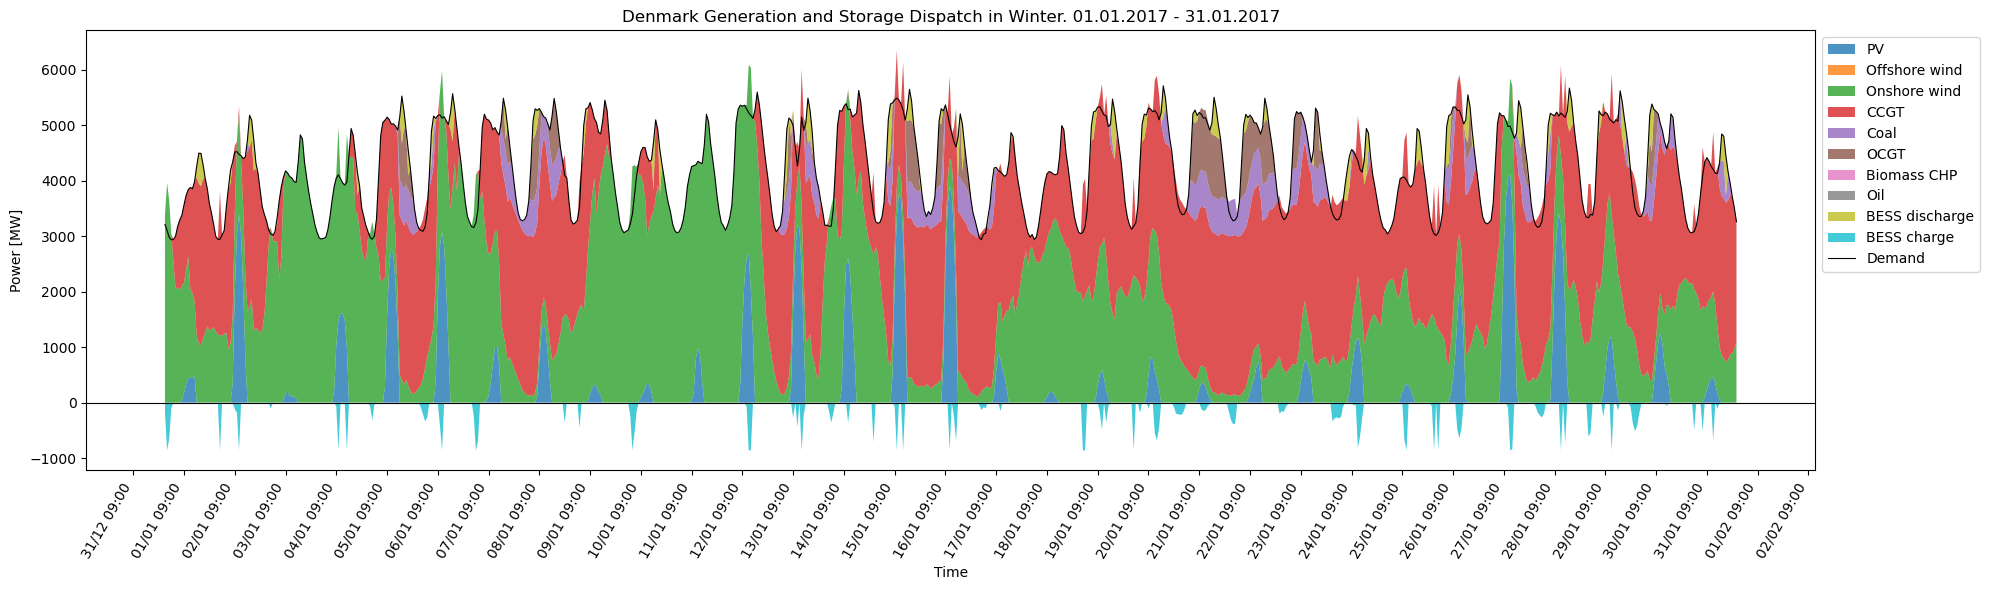

In [128]:
import numpy as np
# Date range winter week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-31 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Denmark Generation and Storage Dispatch in Winter. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Denmark Generation and Storage Dispatch in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Summer week

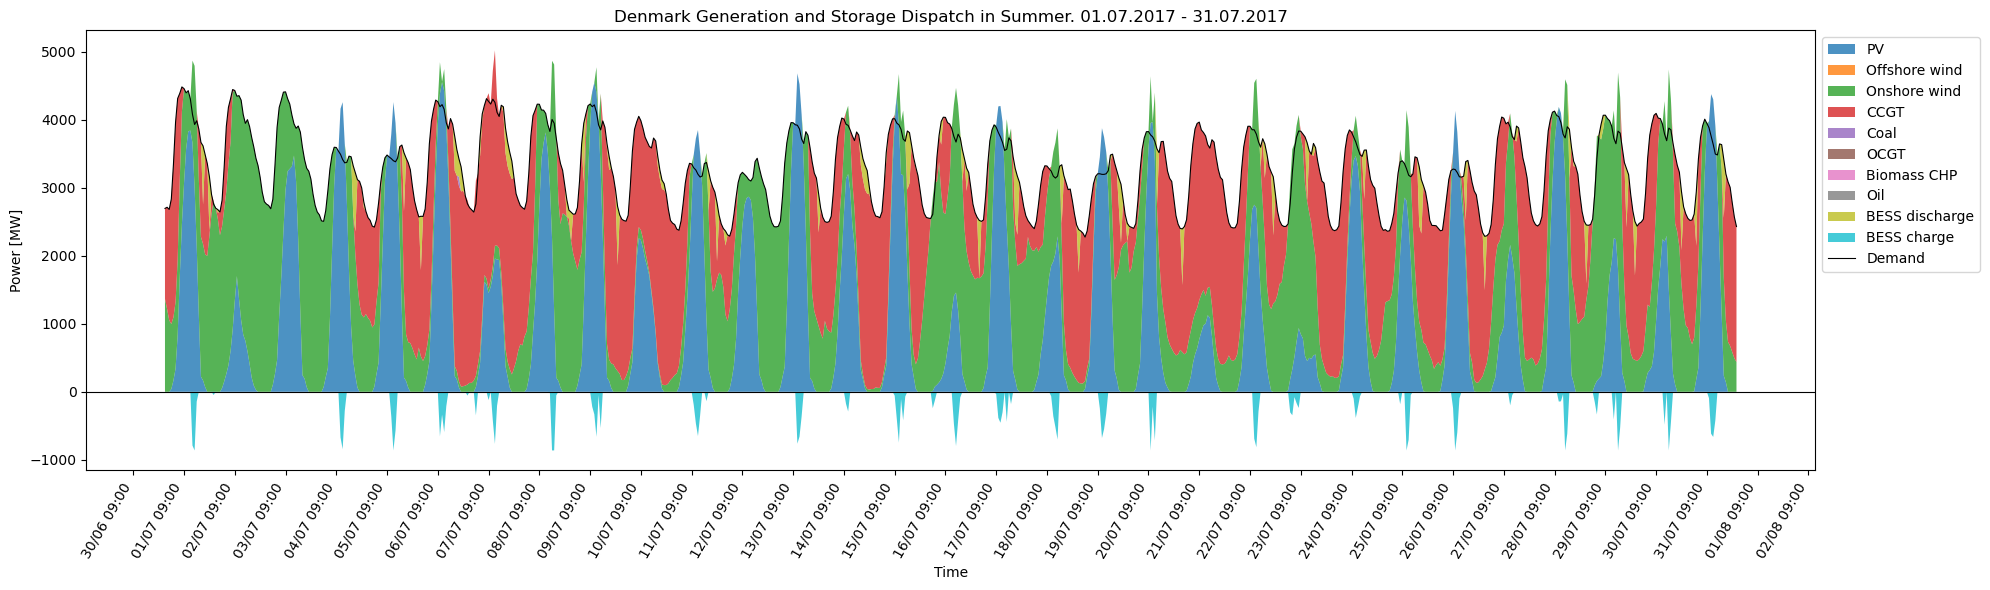

In [129]:
import numpy as np
# Date range week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Denmark Generation and Storage Dispatch in Summer. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Denmark Generation and Storage Dispatch in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [130]:
# Generators
gen_capacity = n.generators[["carrier", "p_nom_opt"]].copy()
gen_capacity["Technology"] = gen_capacity["carrier"].map(n.carriers.nice_name)

# Storage units
su_capacity = n.storage_units[["carrier", "p_nom_opt"]].copy()
su_capacity["Technology"] = su_capacity["carrier"].map(n.carriers.nice_name)

# Combine
capacity = pd.concat([
    gen_capacity[["Technology", "p_nom_opt"]],
    su_capacity[["Technology", "p_nom_opt"]]
], axis=0)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")

print(capacity_table)

Year used for simulation: 2017
Technology
Onshore wind     8227.0
PV               6949.0
CCGT             2873.2
OCGT             1110.0
BESS              862.5
Coal              650.0
Biomass CHP         0.0
Oil                 0.0
Offshore wind       0.0
Name: p_nom_opt, dtype: float64


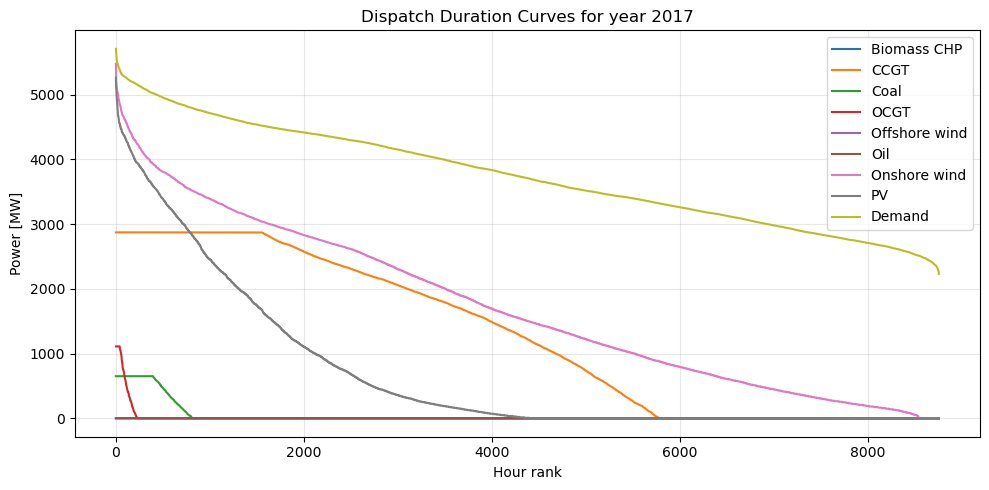

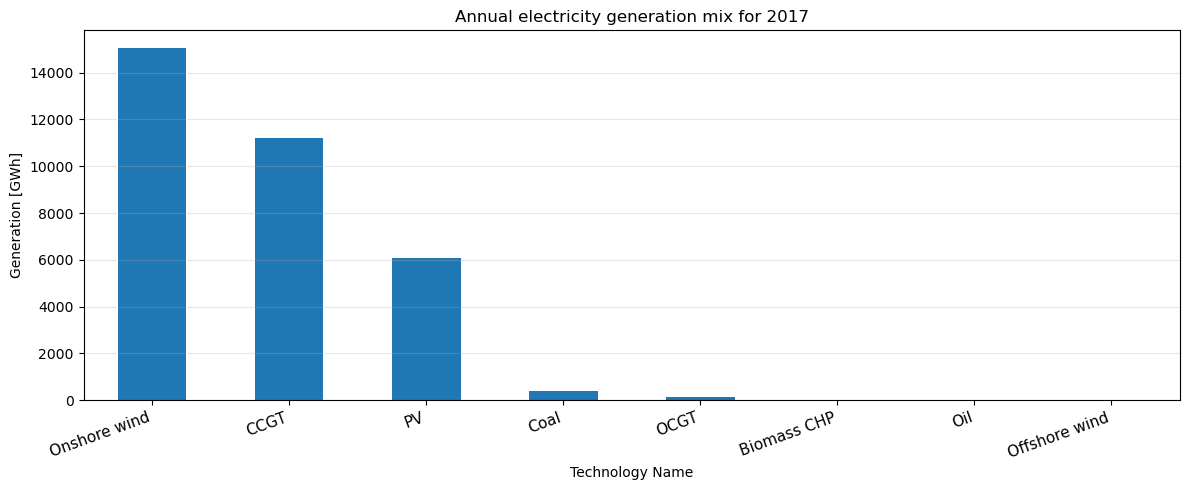


Annual storage operation:


,discharge_mwh,discharge_gwh,charge_mwh,charge_gwh
name,,,,
BESS,512115.381086,512.115381,555680.752046,555.680752


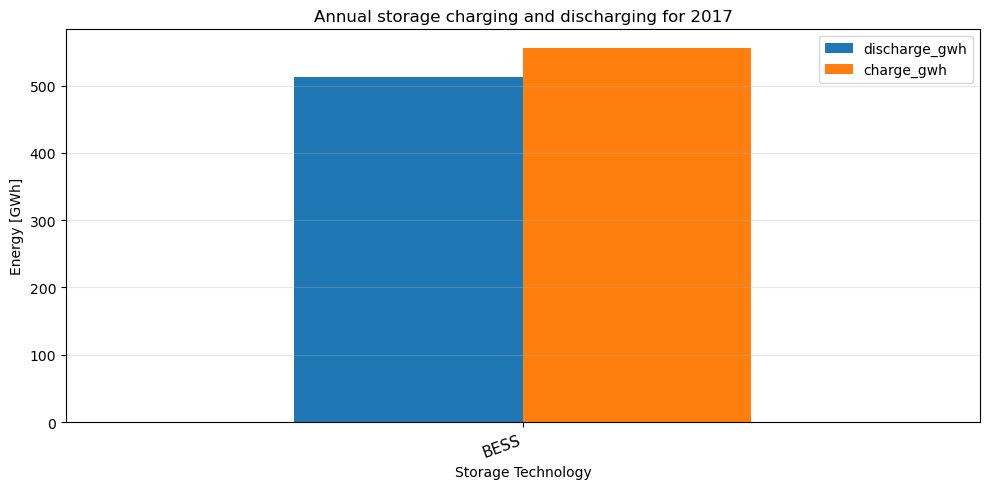

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# GENERATOR DISPATCH
# ----------------------------
gen_dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = gen_dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Add demand if you want it for duration curves
dispatch_nice["Demand"] = work_df["demand_mw"]

# ----------------------------
# DURATION CURVES
# ----------------------------
duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

fig, ax = plt.subplots(figsize=(10, 5))
duration_df.plot(ax=ax)

ax.set_title(f"Dispatch Duration Curves for year {capacity_factor_year}")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# ANNUAL GENERATION MIX
# Only true generators are included in the mix
# Batteries are NOT generation, so they are excluded from shares
# ----------------------------
annual_generation = dispatch_nice.drop(columns="Demand", errors="ignore").sum(axis=0)

annual_generation_df = annual_generation.to_frame(name="generation_mwh")
annual_generation_df["generation_gwh"] = annual_generation_df["generation_mwh"] / 1000

annual_generation_df["share"] = (
    annual_generation_df["generation_mwh"] /
    annual_generation_df["generation_mwh"].sum()
)
annual_generation_df["share_percent"] = 100 * annual_generation_df["share"]

annual_generation_df = annual_generation_df.sort_values("generation_mwh", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
annual_generation_df["generation_gwh"].plot.bar(ax=ax)

ax.set_ylabel("Generation [GWh]")
ax.set_xlabel("Technology Name")
ax.set_title(f"Annual electricity generation mix for {capacity_factor_year}")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# BATTERY DISCHARGE / CHARGE SUMMARY
# Shown separately because storage shifts energy, it does not generate it
# ----------------------------
storage_dispatch = n.storage_units_t.p.copy()

if not storage_dispatch.empty:
    su_carrier_series = n.storage_units.carrier

    storage_dispatch_nice = storage_dispatch.rename(
        columns=lambda s: nice_name_map.get(su_carrier_series[s], su_carrier_series[s])
    )
    storage_dispatch_nice = storage_dispatch_nice.T.groupby(level=0).sum().T

    # Positive = discharge, Negative = charge
    storage_discharge = storage_dispatch_nice.clip(lower=0)
    storage_charge = -storage_dispatch_nice.clip(upper=0)

    annual_storage_discharge = storage_discharge.sum(axis=0)
    annual_storage_charge = storage_charge.sum(axis=0)

    annual_storage_df = pd.DataFrame({
        "discharge_mwh": annual_storage_discharge,
        "discharge_gwh": annual_storage_discharge / 1000,
        "charge_mwh": annual_storage_charge,
        "charge_gwh": annual_storage_charge / 1000,
    }).sort_values("discharge_mwh", ascending=False)

    print("\nAnnual storage operation:")
    display(annual_storage_df)

    # Optional storage plot
    fig, ax = plt.subplots(figsize=(10, 5))
    annual_storage_df[["discharge_gwh", "charge_gwh"]].plot.bar(ax=ax)

    ax.set_ylabel("Energy [GWh]")
    ax.set_xlabel("Storage Technology")
    ax.set_title(f"Annual storage charging and discharging for {capacity_factor_year}")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No storage units found in the model.")

# Part D

### NEW COUNTRIES
Norway

Sweden

Great Britain

In [144]:
# Don't allow to have the 10 year average anymore as a CF setting
capacity_factor_year = 2017
if capacity_factor_year is None:
    capacity_factor_year = 2015

# Collect demand and capacity factors of new countries
offshore_wind_cf_df_raw = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
onshore_wind_cf_df_raw = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
pv_cf_df_raw = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")
el_demand_raw = pd.read_csv("../data/electricity_demand.csv", delimiter=";")

# Collect hydro values
hydro_hourly = pd.read_csv("../data/hydro_hourly.csv",delimiter=",")
hydro_hourly["utc_time"] = pd.to_datetime(hydro_hourly["utc_time"], utc=True, errors="raise")


# Convert ISO8601 to datetime
offshore_wind_cf_df_raw["utc_time"] = pd.to_datetime(offshore_wind_cf_df_raw["utc_time"], utc=True, errors="raise")
onshore_wind_cf_df_raw["utc_time"] = pd.to_datetime(onshore_wind_cf_df_raw["utc_time"], utc=True, errors="raise")
pv_cf_df_raw["utc_time"] = pd.to_datetime(pv_cf_df_raw["utc_time"], utc=True, errors="raise")
el_demand_raw["utc_time"] = pd.to_datetime(el_demand_raw["utc_time"], utc=True, errors="raise")

# Filter out the exact year
pv_cf_df_raw = pv_cf_df_raw[pv_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
onshore_wind_cf_df_raw = onshore_wind_cf_df_raw[onshore_wind_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
offshore_wind_cf_df_raw = offshore_wind_cf_df_raw[offshore_wind_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
el_demand_raw["utc_time"] = el_demand_raw["utc_time"].apply(lambda t: t.replace(year=capacity_factor_year))
hydro_hourly = hydro_hourly[hydro_hourly["utc_time"].dt.year == capacity_factor_year]

# Norway
df_pv_no = pv_cf_df_raw[["utc_time", "NOR"]]
df_onshore_wind_no = onshore_wind_cf_df_raw[["utc_time", "NOR"]]
df_offshore_wind_no = offshore_wind_cf_df_raw[["utc_time", "NOR"]]
el_demand_no = el_demand_raw[["utc_time", "NOR"]]
hydro_df_no = hydro_hourly["NO"]

# Denmark
df_pv_dk = pv_cf_df_raw[["utc_time", "DNK"]]
df_onshore_wind_dk = onshore_wind_cf_df_raw[["utc_time", "DNK"]]
df_offshore_wind_dk = offshore_wind_cf_df_raw[["utc_time", "DNK"]]
el_demand_dk = el_demand_raw[["utc_time", "DNK"]]

# Sweden
df_pv_swe = pv_cf_df_raw[["utc_time", "SWE"]]
df_onshore_wind_swe = onshore_wind_cf_df_raw[["utc_time", "SWE"]]
df_offshore_wind_swe = offshore_wind_cf_df_raw[["utc_time", "SWE"]]
el_demand_swe = el_demand_raw[["utc_time", "SWE"]]
hydro_df_se = hydro_hourly["SE"]

# Great Britain
df_pv_gbr = pv_cf_df_raw[["utc_time", "GBR"]]
df_onshore_wind_gbr = onshore_wind_cf_df_raw[["utc_time", "GBR"]]
df_offshore_wind_gbr = offshore_wind_cf_df_raw[["utc_time", "GBR"]]
el_demand_gbr = el_demand_raw[["utc_time", "GBR"]]
hydro_df_gb = hydro_hourly["GB"]

# Rename columns
df_pv_dk = df_pv_dk.rename(columns={"DNK": "cf"})
df_onshore_wind_dk = df_onshore_wind_dk.rename(columns={"DNK": "cf"})
df_offshore_wind_dk = df_offshore_wind_dk.rename(columns={"DNK": "cf"})

df_pv_no = df_pv_no.rename(columns={"NOR": "cf"})
df_onshore_wind_no = df_onshore_wind_no.rename(columns={"NOR": "cf"})
df_offshore_wind_no = df_offshore_wind_no.rename(columns={"NOR": "cf"})

df_pv_swe = df_pv_swe.rename(columns={"SWE": "cf"})
df_onshore_wind_swe = df_onshore_wind_swe.rename(columns={"SWE": "cf"})
df_offshore_wind_swe = df_offshore_wind_swe.rename(columns={"SWE": "cf"})

df_pv_gbr = df_pv_gbr.rename(columns={"GBR": "cf"})
df_onshore_wind_gbr = df_onshore_wind_gbr.rename(columns={"GBR": "cf"})
df_offshore_wind_gbr = df_offshore_wind_gbr.rename(columns={"GBR": "cf"})

# Remove year from capacity factor dataframes
df_pv_dk = hourly_climatology(df_pv_dk)
df_onshore_wind_dk = hourly_climatology(df_onshore_wind_dk)
df_offshore_wind_dk = hourly_climatology(df_offshore_wind_dk)

df_pv_no = hourly_climatology(df_pv_no)
df_onshore_wind_no = hourly_climatology(df_onshore_wind_no)
df_offshore_wind_no = hourly_climatology(df_offshore_wind_no)

df_pv_swe = hourly_climatology(df_pv_swe)
df_onshore_wind_swe = hourly_climatology(df_onshore_wind_swe)
df_offshore_wind_swe = hourly_climatology(df_offshore_wind_swe)

df_pv_gbr = hourly_climatology(df_pv_gbr)
df_onshore_wind_gbr = hourly_climatology(df_onshore_wind_gbr)
df_offshore_wind_gbr = hourly_climatology(df_offshore_wind_gbr)


# Pull converted data
df_pv_dk = df_pv_dk[["datetime", "cf"]]
df_onshore_wind_dk = df_onshore_wind_dk[["datetime", "cf"]]
df_offshore_wind_dk = df_offshore_wind_dk[["datetime", "cf"]]

df_pv_no = df_pv_no[["datetime", "cf"]]
df_onshore_wind_no = df_onshore_wind_no[["datetime", "cf"]]
df_offshore_wind_no = df_offshore_wind_no[["datetime", "cf"]]

df_pv_swe = df_pv_swe[["datetime", "cf"]]
df_onshore_wind_swe = df_onshore_wind_swe[["datetime", "cf"]]
df_offshore_wind_swe = df_offshore_wind_swe[["datetime", "cf"]]

df_pv_gbr = df_pv_gbr[["datetime", "cf"]]
df_onshore_wind_gbr = df_onshore_wind_gbr[["datetime", "cf"]]
df_offshore_wind_gbr = df_offshore_wind_gbr[["datetime", "cf"]]

# Rename columns
df_pv_dk = df_pv_dk.rename(columns={"cf": "pv_cf_dk"})
df_onshore_wind_dk = df_onshore_wind_dk.rename(columns={"cf": "onshore_cf_dk"})
df_offshore_wind_dk = df_offshore_wind_dk.rename(columns={"cf": "offshore_cf_dk"})

df_pv_no = df_pv_no.rename(columns={"cf": "pv_cf_no"})
df_onshore_wind_no = df_onshore_wind_no.rename(columns={"cf": "onshore_cf_no"})
df_offshore_wind_no = df_offshore_wind_no.rename(columns={"cf": "offshore_cf_no"})

df_pv_swe = df_pv_swe.rename(columns={"cf": "pv_cf_se"})
df_onshore_wind_swe = df_onshore_wind_swe.rename(columns={"cf": "onshore_cf_se"})
df_offshore_wind_swe = df_offshore_wind_swe.rename(columns={"cf": "offshore_cf_se"})

df_pv_gbr = df_pv_gbr.rename(columns={"cf": "pv_cf_gb"})
df_onshore_wind_gbr = df_onshore_wind_gbr.rename(columns={"cf": "onshore_cf_gb"})
df_offshore_wind_gbr = df_offshore_wind_gbr.rename(columns={"cf": "offshore_cf_gb"})

el_demand_dk = el_demand_dk.rename(columns={"DNK": "el_demand_dk"})
el_demand_no = el_demand_no.rename(columns={"NOR": "el_demand_no"})
el_demand_swe = el_demand_swe.rename(columns={"SWE": "el_demand_swe"})
el_demand_gbr = el_demand_gbr.rename(columns={"GBR": "el_demand_gbr"})

# Set index
df_pv_dk = df_pv_dk.set_index("datetime")
df_onshore_wind_dk = df_onshore_wind_dk.set_index("datetime")
df_offshore_wind_dk = df_offshore_wind_dk.set_index("datetime")

df_pv_no = df_pv_no.set_index("datetime")
df_onshore_wind_no = df_onshore_wind_no.set_index("datetime")
df_offshore_wind_no = df_offshore_wind_no.set_index("datetime")

df_pv_swe = df_pv_swe.set_index("datetime")
df_onshore_wind_swe = df_onshore_wind_swe.set_index("datetime")
df_offshore_wind_swe = df_offshore_wind_swe.set_index("datetime")

df_pv_gbr = df_pv_gbr.set_index("datetime")
df_onshore_wind_gbr = df_onshore_wind_gbr.set_index("datetime")
df_offshore_wind_gbr = df_offshore_wind_gbr.set_index("datetime")

el_demand_dk = el_demand_dk.set_index("utc_time")
el_demand_no = el_demand_no.set_index("utc_time")
el_demand_swe = el_demand_swe.set_index("utc_time")
el_demand_gbr = el_demand_gbr.set_index("utc_time")

el_demand_dk.index = pd.to_datetime(el_demand_dk.index).tz_localize(None)
el_demand_no.index = pd.to_datetime(el_demand_no.index).tz_localize(None)
el_demand_swe.index = pd.to_datetime(el_demand_swe.index).tz_localize(None)
el_demand_gbr.index = pd.to_datetime(el_demand_gbr.index).tz_localize(None)

# Concat the dataframes
work_df = pd.concat([df_pv_dk, df_onshore_wind_dk, df_offshore_wind_dk, df_pv_no, df_onshore_wind_no, 
                     df_offshore_wind_no, df_pv_swe, df_onshore_wind_swe, df_offshore_wind_swe, df_pv_gbr, df_onshore_wind_gbr,
                       df_offshore_wind_gbr], axis=1)
work_df.index = pd.to_datetime(
    str(capacity_factor_year) + "/" + work_df.index.astype(str),
    format="%Y/%d/%m %H:%M"
)

work_df = work_df.join(
    [el_demand_no, el_demand_dk, el_demand_swe, el_demand_gbr],
    how="left"
)


In [145]:
# New technologies: hydro, nuclear

# Technology lifetimes
hydro_lifetime = 60 # years
nuclear_lifetime = 60 # years

# CAPEX
hydro_capex = 1720000 # EUR/MW
nuclear_capex = 5500000 # EUR/MW

# Annualised capital costs
annualised_hydro_capex = hydro_capex / hydro_lifetime # EUR/MW/year
annualsied_nuclear_capex = nuclear_capex / nuclear_lifetime # EUR/MW/year

# Annual OPEX costs
hydro_opex = 20*1000 # EUR/MW/year
nuclear_opex = 150 * 1000 # EUR/MW/year

# Setting up marginal generation costs
nuclear_marginal_cost = 14 # EUR/MWh
hydro_marginal_cost = 2 # EUR/MWh


In [152]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Fix hydro index
hydro_df_gb.index = n.snapshots
hydro_df_se.index = n.snapshots
hydro_df_no.index = n.snapshots

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)

n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

n.add(
    "Carrier",
    "Hydro",
    co2_emissions=0,
    nice_name="Hydro"
)

n.add(
    "Carrier",
    "Nuclear",
    co2_emissions=0,
    nice_name="Nuclear"
)

n.add(
    "Carrier",
    "Coal",
    co2_emissions=0,
    nice_name="Coal"
)

n.add(
    "Carrier",
    "Oil",
    co2_emissions=0,
    nice_name="Oil"
)

n.add(
    "Carrier",
    "BESS",
    co2_emissions=0,
    nice_name="BESS"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
    v_nom=400
)

n.add(
    "Bus",
    "SWE",
    carrier="AC",
    v_nom=400
)

n.add(
    "Bus",
    "NO",
    carrier="AC",
    v_nom=400
)

n.add(
    "Bus",
    "GB",
    carrier="AC",
    v_nom=400
)


# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["el_demand_dk"].to_numpy()
)

n.add(
    "Load",
    "SWELoad",
    bus="SWE",
    p_set=work_df["el_demand_swe"].to_numpy()
)
n.add(
    "Load",
    "NOLoad",
    bus="NO",
    p_set=work_df["el_demand_no"].to_numpy()
)
n.add(
    "Load",
    "GBRLoad",
    bus="GB",
    p_set=work_df["el_demand_gbr"].to_numpy()
)

# --- DK Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_nom = 2650,
    p_max_pu = work_df["offshore_cf_dk"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_nom= 4860,
    p_max_pu = work_df["onshore_cf_dk"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_nom=4800,
    p_max_pu = work_df["pv_cf_dk"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex + pv_opex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    p_nom=2000,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex + chp_opex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    p_nom=1750,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex + ccgt_opex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex + ocgt_opex),
)

n.add(
    "Generator",
    "DKCoal",
    bus="DK",
    carrier="Coal",
    p_nom_extendable=False,
    p_nom=650,
    marginal_cost=coal_marginal_cost,
    capital_cost=annualised_coal_capex + coal_opex,
)

n.add(
    "Generator",
    "DKOil",
    bus="DK",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=300,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex,
)

# --- UK generators ---
n.add(
    "StorageUnit",
    "GBHydro",
    bus="GB",
    carrier="Hydro",
    p_nom=2000,
    max_hours=450, # GB reservoir size
    p_nom_extendable=False,
    efficiency_dispatch=0.9,
    standing_loss=0.0,
    cyclic_state_of_charge=False,
    state_of_charge_initial=0.5 * 2000 * 450,
    marginal_cost=hydro_marginal_cost,
    capital_cost=annualised_hydro_capex + hydro_opex,
)
n.storage_units_t.inflow["GBHydro"] = hydro_df_gb

n.add(
    "Generator",
    "GBWind",
    bus="GB",
    carrier="OnshoreWind",
    p_nom=32000,
    p_max_pu = work_df["onshore_cf_gb"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost= annualised_onshore_wind_capex + onshore_wind_opex
)

n.add(
    "Generator",
    "GBPV",
    bus="GB",
    carrier="PV",
    p_nom=15000,
    p_max_pu = work_df["pv_cf_gb"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(pv_marginal_cost),
    capital_cost = annualised_pv_capex + pv_opex
)

n.add(
    "Generator",
    "GBNuclear",
    bus="GB",
    carrier="Nuclear",
    p_nom=7000,
    p_nom_extendable=True,
    marginal_cost=nuclear_marginal_cost,
    capital_cost = annualsied_nuclear_capex + nuclear_opex

)

n.add(
    "Generator",
    "GBCCGT",
    bus="GB",
    carrier="CCGT",
    p_nom=33000,
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=annualised_ccgt_capex + ccgt_opex
)

n.add(
    "Generator",
    "GBBiomassCHP",
    bus="GB",
    carrier="BiomassCHP",
    p_nom=7000,
    p_nom_extendable=True,
    marginal_cost=chp_marginal_cost,
    capital_cost=annualised_chp_capex + chp_opex
)

n.add(
    "Generator",
    "GBOil",
    bus="GB",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=2000,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex
)

# --- Sweden generators ---
n.add(
    "StorageUnit",
    "SEHydro",
    bus="SWE",
    carrier="Hydro",
    p_nom=16000,
    max_hours=2125, # Sweden reservoir size
    p_nom_extendable=False,
    efficiency_dispatch=0.9,
    standing_loss=0.0,
    cyclic_state_of_charge=False,
    state_of_charge_initial=0.5 * 16000 * 2125,
    marginal_cost=hydro_marginal_cost,
    capital_cost=annualised_hydro_capex + hydro_opex,
)
n.storage_units_t.inflow["SEHydro"] = hydro_df_se

n.add(
    "Generator",
    "SEWind",
    bus="SWE",
    carrier="OnshoreWind",
    p_nom=16000,
    p_max_pu = work_df["onshore_cf_se"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=annualised_onshore_wind_capex + onshore_wind_opex
)

n.add(
    "Generator",
    "SEPV",
    bus="SWE",
    carrier="PV",
    p_nom=3000,
    p_max_pu = work_df["pv_cf_se"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(pv_marginal_cost),
    capital_cost=annualised_pv_capex + pv_opex
)

n.add(
    "Generator",
    "SENuclear",
    bus="SWE",
    carrier="Nuclear",
    p_nom=7500,
    p_nom_extendable=True,
    marginal_cost=nuclear_marginal_cost,
    capital_cost=annualsied_nuclear_capex + nuclear_opex
)

n.add(
    "Generator",
    "SECCGT",
    bus="SWE",
    carrier="CCGT",
    p_nom=2000,
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=annualised_ccgt_capex + ccgt_opex
)

n.add(
    "Generator",
    "SEBiomassCHP",
    bus="SWE",
    carrier="BiomassCHP",
    p_nom=5000,
    p_nom_extendable=True,
    marginal_cost=chp_marginal_cost,
    capital_cost=annualised_chp_capex + chp_opex

)

n.add(
    "Generator",
    "SEOil",
    bus="SWE",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex
)

# --- Norway generators ---
n.add(
    "StorageUnit",
    "NOHydro",
    bus="NO",
    carrier="Hydro",
    p_nom=34000, # MW turbine capacity
    max_hours=2500, # Norway reservoir size
    p_nom_extendable=False,
    efficiency_dispatch=0.9,
    standing_loss=0.0,
    cyclic_state_of_charge=False,
    state_of_charge_initial=0.5 * 34000 * 2500,
    marginal_cost=hydro_marginal_cost,
    capital_cost=annualised_hydro_capex + hydro_opex,
)

n.storage_units_t.inflow["NOHydro"] = hydro_df_no

n.add(
    "Generator",
    "NOWind",
    bus="NO",
    carrier="OnshoreWind",
    p_nom=5000,
    p_max_pu = work_df["onshore_cf_no"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=annualised_onshore_wind_capex + onshore_wind_opex
)

n.add(
    "Generator",
    "NOCCGT",
    bus="NO",
    carrier="CCGT",
    p_nom=1500,
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=annualised_ccgt_capex + ccgt_opex
)

n.add(
    "Generator",
    "NOOil",
    bus="NO",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=100,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex
)

# --- Lines ---
n.add(
    "Line",
    "DK-SWE",
    bus0="DK",
    bus1="SWE",
    s_nom=2415, #MW
    x = 0.1,
    r = 0
)

n.add(
    "Line",
    "SWE-NO",
    bus0="SWE",
    bus1="NO",
    s_nom=4000, #MW
    x = 0.1,
    r = 0
)

n.add(
    "Line",
    "NO-DK",
    bus0="NO",
    bus1="DK",
    s_nom=1700, #MW
    x = 0.1,
    r = 0
)

n.add(
    "Line",
    "DK-GB",
    bus0="DK",
    bus1="GB",
    s_nom=1400, #MW
    x = 0.1,
    r = 0
)


# --- Storage Units ---
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex

n.add(
    "StorageUnit",
    "DKBESS",
    bus="DK",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=100,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

n.add(
    "StorageUnit",
    "NOBESS",
    bus="NO",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=125,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

n.add(
    "StorageUnit",
    "SEBESS",
    bus="SWE",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=450,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

n.add(
    "StorageUnit",
    "GBBESS",
    bus="GB",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=6900,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)


In [153]:
n.lines[["bus0", "bus1", "x", "r", "s_nom", "s_nom_extendable"]].T

name,DK-SWE,SWE-NO,NO-DK,DK-GB
bus0,DK,SWE,NO,DK
bus1,SWE,NO,DK,GB
x,0.1,0.1,0.1,0.1
r,0.0,0.0,0.0,0.0
s_nom,2415.0,4000.0,1700.0,1400.0
s_nom_extendable,False,False,False,False


In [156]:
n.buses[["v_nom", "carrier"]].T

name,DK,SWE,NO,GB
v_nom,400.0,400.0,400.0,400.0
carrier,AC,AC,AC,AC


In [157]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT,DKCoal,DKOil,GBWind,GBPV,...,GBOil,SEWind,SEPV,SENuclear,SECCGT,SEBiomassCHP,SEOil,NOWind,NOCCGT,NOOil
bus,DK,DK,DK,DK,DK,DK,DK,DK,GB,GB,...,GB,SWE,SWE,SWE,SWE,SWE,SWE,NO,NO,NO
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT,Coal,Oil,OnshoreWind,PV,...,Oil,OnshoreWind,PV,Nuclear,CCGT,BiomassCHP,Oil,OnshoreWind,CCGT,Oil
p_nom,2650.0,4860.0,4800.0,2000.0,1750.0,750.0,650.0,300.0,32000.0,15000.0,...,2000.0,16000.0,3000.0,7500.0,2000.0,5000.0,750.0,5000.0,1500.0,100.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,123333.333333,55666.666667,24785.714286,350000.0,66500.0,44000.0,106111.111111,63125.0,55666.666667,24785.714286,...,63125.0,55666.666667,24785.714286,241666.666667,66500.0,350000.0,63125.0,55666.666667,66500.0,63125.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5,76.368421,321.666667,4.0,0.0,...,321.666667,4.0,0.0,14.0,57.131579,115.0,321.666667,4.0,57.131579,321.666667


In [158]:
n.storage_units[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,GBHydro,SEHydro,NOHydro,DKBESS,NOBESS,SEBESS,GBBESS
bus,GB,SWE,NO,DK,NO,SWE,GB
carrier,Hydro,Hydro,Hydro,BESS,BESS,BESS,BESS
p_nom,2000.0,16000.0,34000.0,100.0,125.0,450.0,6900.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,48666.666667,48666.666667,48666.666667,36470.588235,36470.588235,36470.588235,36470.588235
marginal_cost,2.0,2.0,2.0,0.0,0.0,0.0,0.0


In [159]:
# Solver
n.optimize(
    solver_name="highs",
    solver_options={
        "threads": 0,
        "presolve": "on",
        "parallel": "on",
        "solver": "simplex",
    }
)

Index(['DK-SWE', 'SWE-NO', 'NO-DK', 'DK-GB'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - threads: 0
 - presolve: on
 - parallel: on
 - solver: simplex
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 125.65it/s]
INFO:linopy.io: Writing time: 1.18s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 446787 primals, 946106 duals
Objective: 4.42e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-ext-p_store-lower, 

('ok', 'optimal')

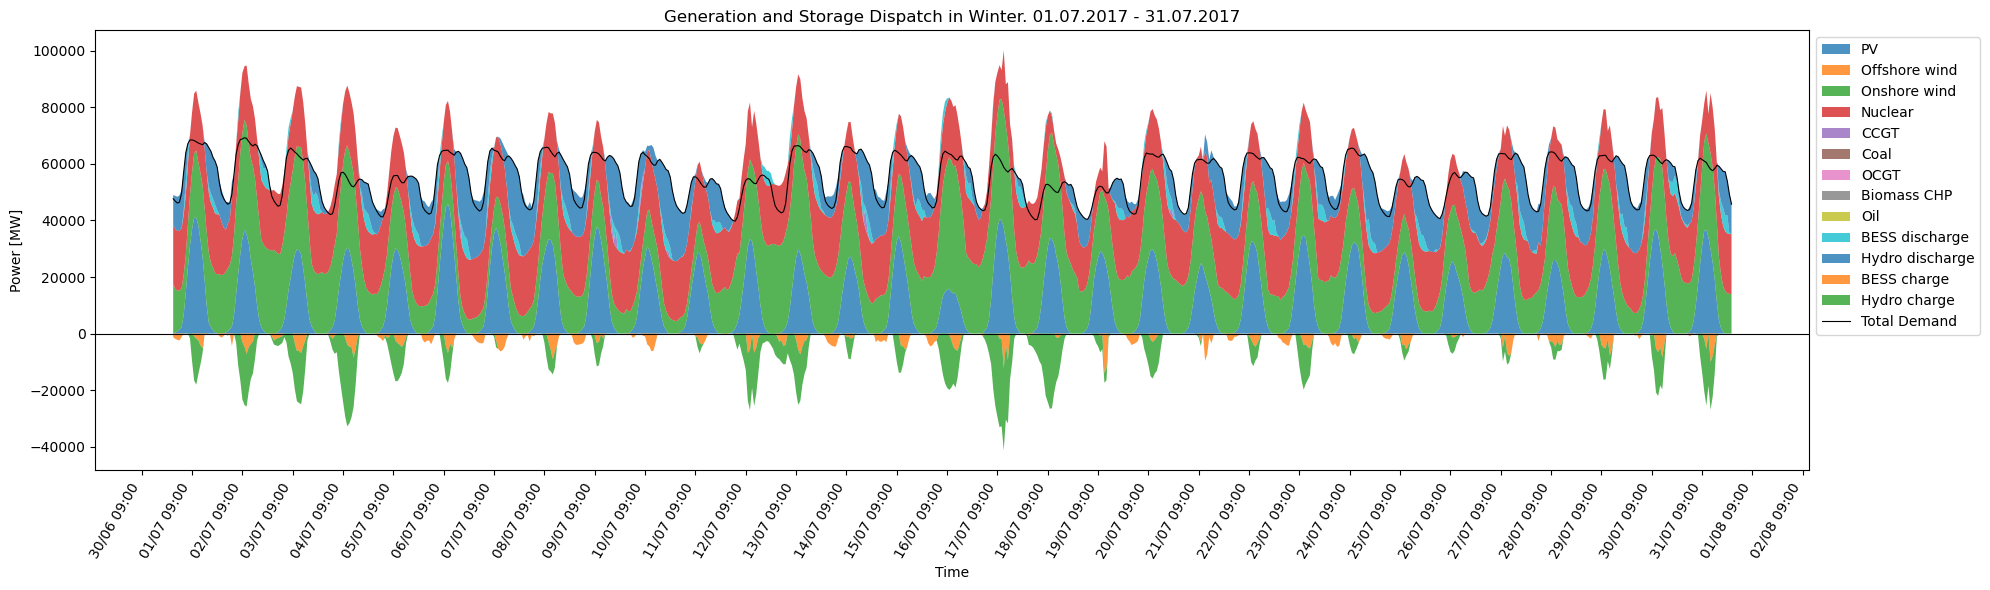

In [160]:
import numpy as np
# Date range winter week

start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_cols = ["el_demand_dk", "el_demand_no", "el_demand_swe", "el_demand_gbr"]
demand_plot = work_df.loc[start_date:end_date, demand_cols].sum(axis=1).copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Total Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Generation and Storage Dispatch in Winter. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Generation and Storage Dispatch in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

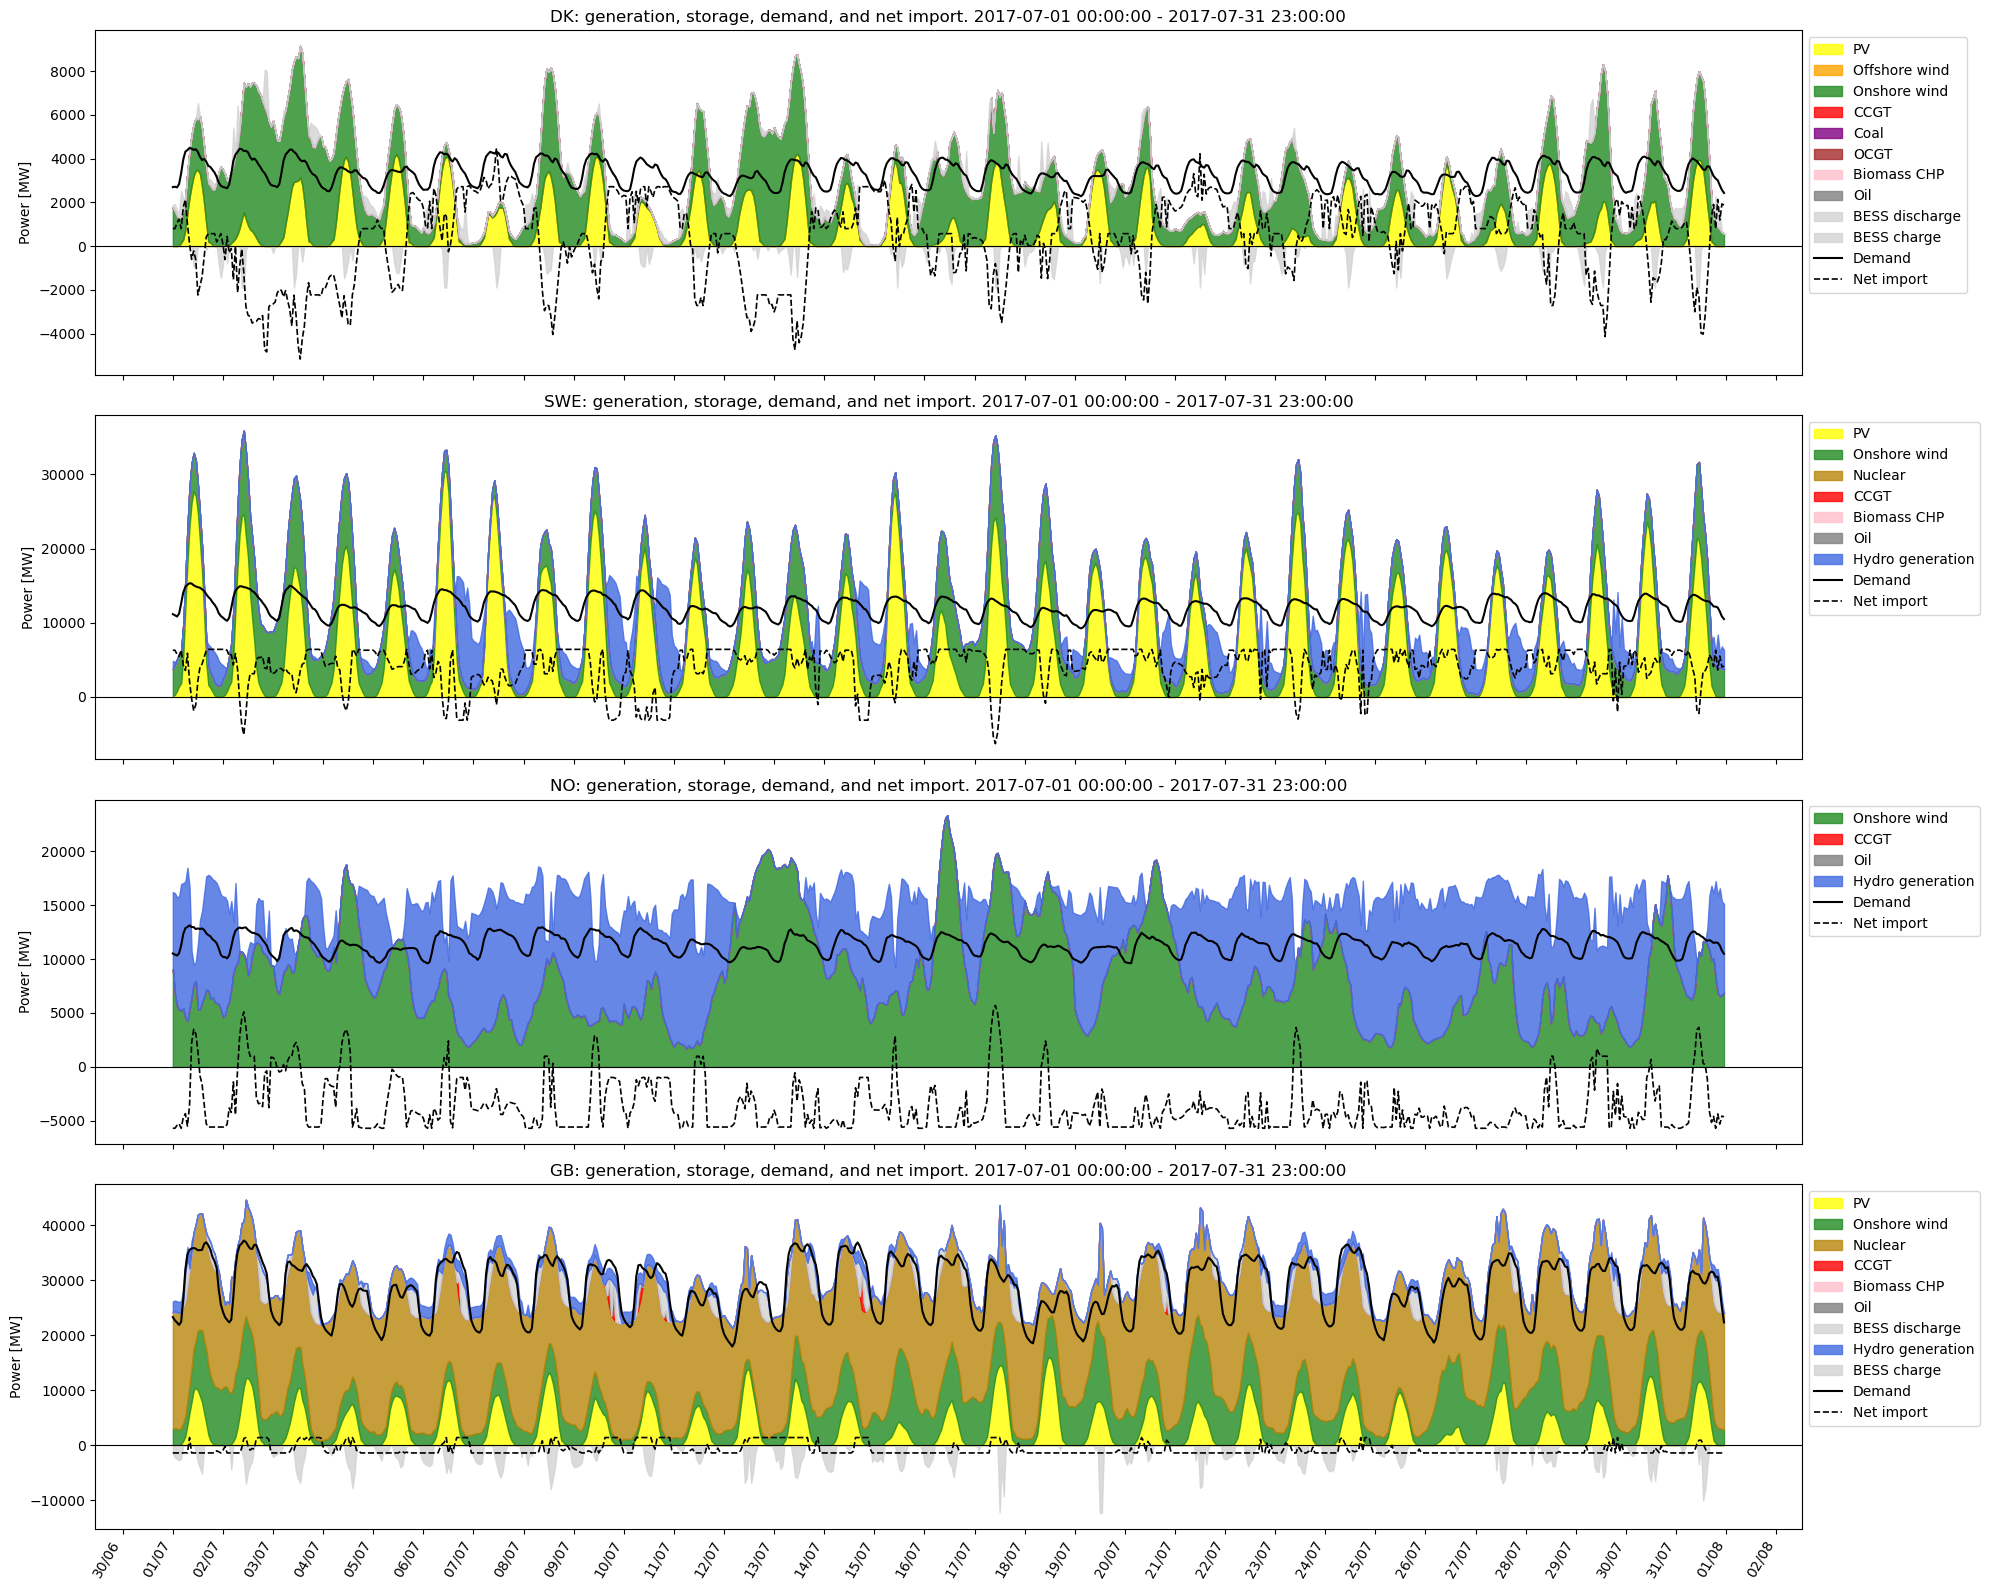

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    "Demand": "black",
    "PV": "yellow",
    "Onshore wind": "forestgreen",
    "Offshore wind": "orange",
    "CCGT": "red",
    "OCGT": "brown",
    "Coal": "purple",
    "Biomass CHP": "pink",
    "Oil": "gray",
    "Hydro": "royalblue",
    "Battery": "olive", 
    "Nuclear": "darkgoldenrod",
    "Battery discharge": "#1b5e20",
    "Battery charge": "#1b5e20"
}

# ----------------------------
# TIME WINDOW
# ----------------------------
start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")

countries = ["DK", "SWE", "NO", "GB"]

# ----------------------------
# GENERATOR DISPATCH BY COUNTRY AND TECH
# ----------------------------
gen_dispatch = n.generators_t.p.loc[start_date:end_date].copy()

gen_meta = n.generators[["bus", "carrier", "marginal_cost"]].copy()
gen_meta["nice_name"] = gen_meta["carrier"].map(n.carriers.nice_name).fillna(gen_meta["carrier"])

# technology order from average marginal cost
tech_order = (
    gen_meta.groupby("nice_name")["marginal_cost"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

# ----------------------------
# STORAGE BY COUNTRY AND TECH
# ----------------------------
storage_dispatch = n.storage_units_t.p.loc[start_date:end_date].copy()

if not storage_dispatch.empty:
    su_meta = n.storage_units[["bus", "carrier"]].copy()
    su_meta["nice_name"] = su_meta["carrier"].map(n.carriers.nice_name).fillna(su_meta["carrier"])
else:
    su_meta = pd.DataFrame(columns=["bus", "carrier", "nice_name"])

# ----------------------------
# LOAD BY COUNTRY
# ----------------------------
load_dispatch = n.loads_t.p_set.loc[start_date:end_date].copy()
load_meta = n.loads[["bus"]].copy()

# ----------------------------
# LINE FLOWS
# ----------------------------
line_p0 = n.lines_t.p0.loc[start_date:end_date].copy()
line_meta = n.lines[["bus0", "bus1"]].copy()

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def get_country_generation(country):
    gens = gen_meta.index[gen_meta["bus"] == country]
    if len(gens) == 0:
        return pd.DataFrame(index=gen_dispatch.index)

    df = gen_dispatch[gens].copy()
    rename_map = gen_meta.loc[gens, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    ordered_cols = [c for c in tech_order if c in df.columns]
    return df[ordered_cols]

def get_country_storage(country):
    sus = su_meta.index[su_meta["bus"] == country]
    if len(sus) == 0:
        empty = pd.DataFrame(index=gen_dispatch.index)
        return empty, empty

    df = storage_dispatch[sus].copy()
    rename_map = su_meta.loc[sus, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    discharge = df.clip(lower=0)
    charge = df.clip(upper=0)
    return discharge, charge

def get_country_demand(country):
    loads = load_meta.index[load_meta["bus"] == country]
    if len(loads) == 0:
        return pd.Series(0.0, index=gen_dispatch.index, name=f"{country}_demand")

    return load_dispatch[loads].sum(axis=1)

def get_country_net_import(country):
    """
    Positive value = net import into country
    Negative value = net export from country
    """
    net_import = pd.Series(0.0, index=line_p0.index)

    for line in line_meta.index:
        bus0 = line_meta.loc[line, "bus0"]
        bus1 = line_meta.loc[line, "bus1"]
        p0 = line_p0[line]

        # p0 > 0 means flow bus0 -> bus1
        # import into bus0 = -p0
        # import into bus1 = +p0
        if country == bus0:
            net_import = net_import - p0
        elif country == bus1:
            net_import = net_import + p0

    return net_import

# ----------------------------
# PLOT COUNTRY-BY-COUNTRY
# ----------------------------
fig, axes = plt.subplots(len(countries), 1, figsize=(20, 4 * len(countries)), sharex=True)

if len(countries) == 1:
    axes = [axes]

for ax, country in zip(axes, countries):
    gen_df = get_country_generation(country)
    storage_discharge_df, storage_charge_df = get_country_storage(country)
    demand = get_country_demand(country)
    net_import = get_country_net_import(country)

    x = gen_df.index if not gen_df.empty else demand.index

    # positive stack: generation
    pos_cum = np.zeros(len(x))
    for col in gen_df.columns:
        y = gen_df[col].to_numpy()
        color = tech_colors.get(col, "lightgray")
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col, color=color)
        pos_cum = pos_cum + y

    # positive stack: storage discharge
    for col in storage_discharge_df.columns:
        y = storage_discharge_df[col].to_numpy()
        if np.any(y != 0):
            label = "Hydro generation" if col == "Hydro" else f"{col} discharge"
            color = tech_colors.get(col, "lightgray")
            ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=label, color=color)
            pos_cum = pos_cum + y

    # negative stack: storage charge
    neg_cum = np.zeros(len(x))
    for col in storage_charge_df.columns:
        if "Hydro" in col:
            continue
        y = storage_charge_df[col].to_numpy()   # negative or zero
        if np.any(y != 0):
            color = tech_colors.get(col, "lightgray")
            ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge", color=color)
            neg_cum = neg_cum + y

    # demand line
    ax.plot(x, demand.to_numpy(), color=tech_colors["Demand"], linewidth=1.5, label="Demand")

    # net import line
    ax.plot(x, net_import.to_numpy(), linestyle="--", linewidth=1.2, color="black", label="Net import")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Power [MW]")
    ax.set_title(f"{country}: generation, storage, demand, and net import. {start_date} - {end_date}")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.setp(axes[-1].get_xticklabels(), rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [169]:
# Show optimal capacities of technologies per country and how much energy each produces per year.

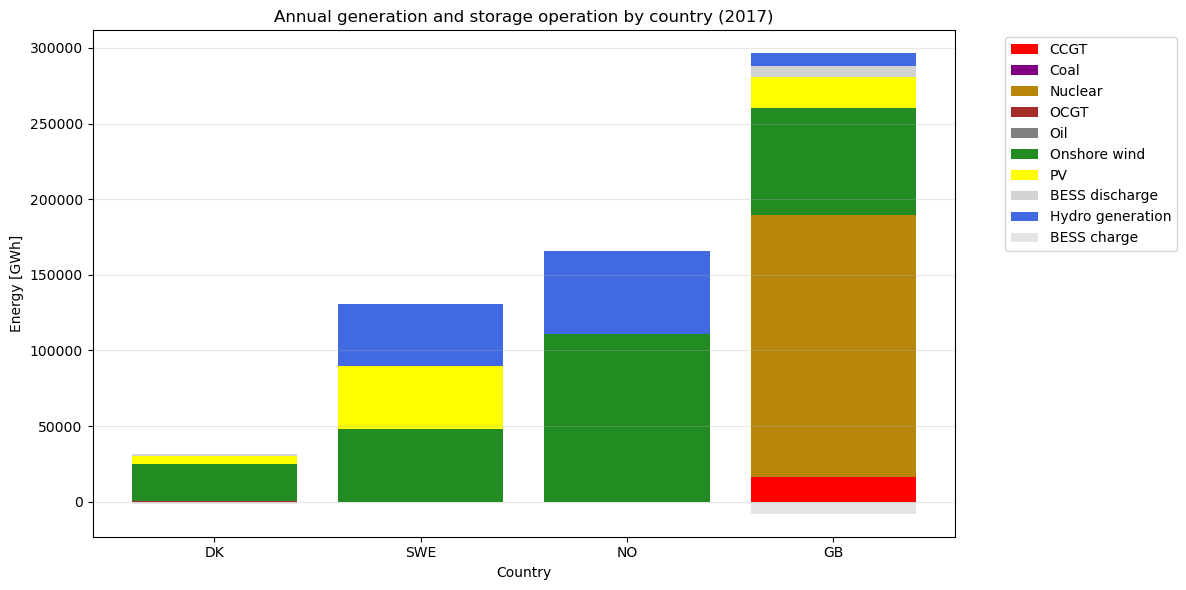

In [179]:
# ----------------------------
# PREPARE GENERATION
# ----------------------------
gen_dispatch_raw = n.generators_t.p.copy()

gen_meta = n.generators[["bus", "carrier"]].copy()
nice_name_map = n.carriers.nice_name.to_dict()

# ----------------------------
# PREPARE STORAGE
# ----------------------------
storage_dispatch_raw = n.storage_units_t.p.copy()

if not storage_dispatch_raw.empty:
    su_meta = n.storage_units[["bus", "carrier"]].copy()

    # Split charge / discharge from RAW data
    storage_discharge_raw = storage_dispatch_raw.clip(lower=0)
    storage_charge_raw = -storage_dispatch_raw.clip(upper=0)

else:
    su_meta = pd.DataFrame(columns=["bus", "carrier"])
    storage_discharge_raw = pd.DataFrame(index=gen_dispatch_raw.index)
    storage_charge_raw = pd.DataFrame(index=gen_dispatch_raw.index)

# ----------------------------
# BUILD COUNTRY-TECH MATRICES
# ----------------------------
countries = n.buses.index.tolist()

gen_techs = sorted(
    set(nice_name_map.get(c, c) for c in n.generators["carrier"].unique())
)
storage_techs = sorted(
    set(nice_name_map.get(c, c) for c in n.storage_units["carrier"].unique())
) if not n.storage_units.empty else []

all_techs = sorted(set(gen_techs) | set(storage_techs))

country_gen = pd.DataFrame(0.0, index=countries, columns=all_techs)
country_storage_dis = pd.DataFrame(0.0, index=countries, columns=all_techs)
country_storage_ch = pd.DataFrame(0.0, index=countries, columns=all_techs)

# --- Generators
for gen in n.generators.index:
    country = n.generators.loc[gen, "bus"]
    tech = nice_name_map.get(n.generators.loc[gen, "carrier"], n.generators.loc[gen, "carrier"])
    country_gen.loc[country, tech] += gen_dispatch_raw[gen].sum()

# --- Storage discharge
for su in n.storage_units.index:
    country = n.storage_units.loc[su, "bus"]
    tech = nice_name_map.get(n.storage_units.loc[su, "carrier"], n.storage_units.loc[su, "carrier"])
    country_storage_dis.loc[country, tech] += storage_discharge_raw[su].sum()

# --- Storage charge
for su in n.storage_units.index:
    country = n.storage_units.loc[su, "bus"]
    tech = nice_name_map.get(n.storage_units.loc[su, "carrier"], n.storage_units.loc[su, "carrier"])

    # Skip hydro charging completely
    if tech == "Hydro":
        continue

    country_storage_ch.loc[country, tech] += storage_charge_raw[su].sum()

# Convert to GWh
country_gen /= 1000
country_storage_dis /= 1000
country_storage_ch /= 1000

# Remove technologies that are zero everywhere
country_gen = country_gen.loc[:, (country_gen != 0).any(axis=0)]
country_storage_dis = country_storage_dis.loc[:, (country_storage_dis != 0).any(axis=0)]
country_storage_ch = country_storage_ch.loc[:, (country_storage_ch != 0).any(axis=0)]

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

countries_plot = country_gen.index
bottom = np.zeros(len(countries_plot))

# generation
for tech in country_gen.columns:
    values = country_gen[tech].values
    if np.any(values > 0):
        ax.bar(
            countries_plot,
            values,
            bottom=bottom,
            label=tech,
            color=tech_colors.get(tech, "lightgray")
        )
        bottom += values

# storage discharge
for tech in country_storage_dis.columns:
    values = country_storage_dis[tech].values
    if np.any(values > 0):
        label = "Hydro generation" if tech == "Hydro" else f"{tech} discharge"
        ax.bar(
            countries_plot,
            values,
            bottom=bottom,
            label=label,
            color=tech_colors.get(tech, "lightgray")
        )
        bottom += values

# storage charge (negative) -- no hydro charge
bottom_neg = np.zeros(len(countries_plot))
for tech in country_storage_ch.columns:
    values = -country_storage_ch[tech].values
    if np.any(values < 0):
        ax.bar(
            countries_plot,
            values,
            bottom=bottom_neg,
            label=f"{tech} charge",
            color=tech_colors.get(tech, "lightgray"),
            alpha=0.6
        )
        bottom_neg += values

ax.set_ylabel("Energy [GWh]")
ax.set_xlabel("Country")
ax.set_title(f"Annual generation and storage operation by country ({capacity_factor_year})")
ax.grid(axis="y", alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [182]:
# ----------------------------
# NUMERIC TABLES PER COUNTRY AND TECHNOLOGY
# Uses:
# - country_gen
# - country_storage_dis
# - country_storage_ch
# from the previous block
# ----------------------------

# Rename for clearer presentation
country_gen_num = country_gen.copy()
country_storage_dis_num = country_storage_dis.copy()
country_storage_ch_num = country_storage_ch.copy()

# Rename storage discharge columns
country_storage_dis_num = country_storage_dis_num.rename(
    columns=lambda c: "Hydro generation" if c == "Hydro" else f"{c} discharge"
)

# Rename storage charge columns
country_storage_ch_num = country_storage_ch_num.rename(
    columns=lambda c: f"{c} charge"
)

# Combine into one table
country_energy_table = pd.concat(
    [country_gen_num, country_storage_dis_num, -country_storage_ch_num],
    axis=1
)

# Group in case names overlap
country_energy_table = country_energy_table.T.groupby(level=0).sum().T

# Round nicely
country_energy_table_rounded = country_energy_table.round(2)

print("Annual generation and storage operation by country [GWh]:")
display(country_energy_table_rounded)

Annual generation and storage operation by country [GWh]:


,BESS charge,BESS discharge,CCGT,Coal,Hydro generation,Nuclear,OCGT,Oil,Onshore wind,PV
DK,-1421.17,1309.75,0.00,79.05,0.00,0.00,69.61,0.0,24691.79,5549.00
SWE,-0.00,0.00,0.00,0.00,41410.73,0.00,0.00,0.0,48166.84,41356.00
NO,0.00,0.00,0.00,0.00,55167.89,0.00,0.00,0.0,110867.61,0.00
GB,-7927.78,7306.25,16571.24,0.00,8238.20,172740.74,0.00,2.0,71202.99,20350.37


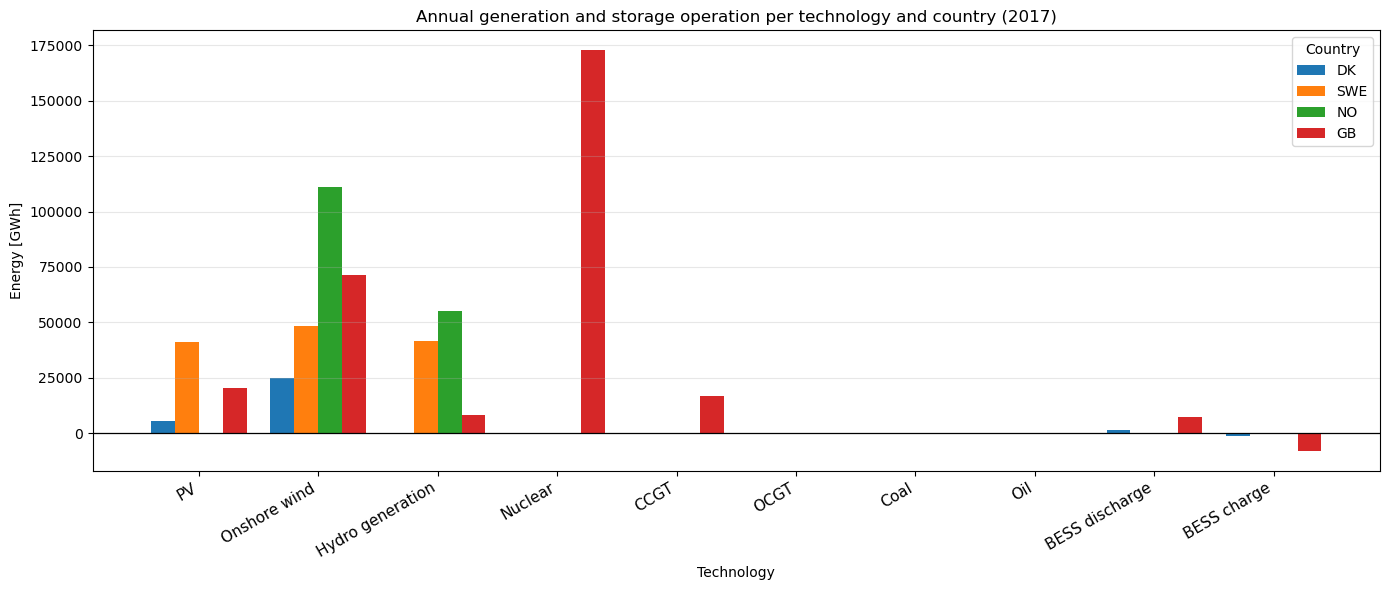

In [185]:
import matplotlib.pyplot as plt
import numpy as np

# Use your table from the screenshot
# rows = countries, columns = technologies
plot_df = country_energy_table.copy()

# Optional: choose order of technologies
desired_order = [
    "PV",
    "Onshore wind",
    "Hydro generation",
    "Nuclear",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
    "BESS discharge",
    "BESS charge",
]
plot_df = plot_df.reindex(columns=[c for c in desired_order if c in plot_df.columns])

# Transpose so technologies are on x-axis
plot_df_t = plot_df.T

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(plot_df_t.index))
n_countries = len(plot_df_t.columns)
width = 0.8 / n_countries

for i, country in enumerate(plot_df_t.columns):
    ax.bar(
        x + (i - (n_countries - 1) / 2) * width,
        plot_df_t[country].values,
        width=width,
        label=country
    )

ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(plot_df_t.index, rotation=30, ha="right", fontsize=11)
ax.set_ylabel("Energy [GWh]")
ax.set_xlabel("Technology")
ax.set_title(f"Annual generation and storage operation per technology and country ({capacity_factor_year})")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Country")

plt.tight_layout()
plt.show()

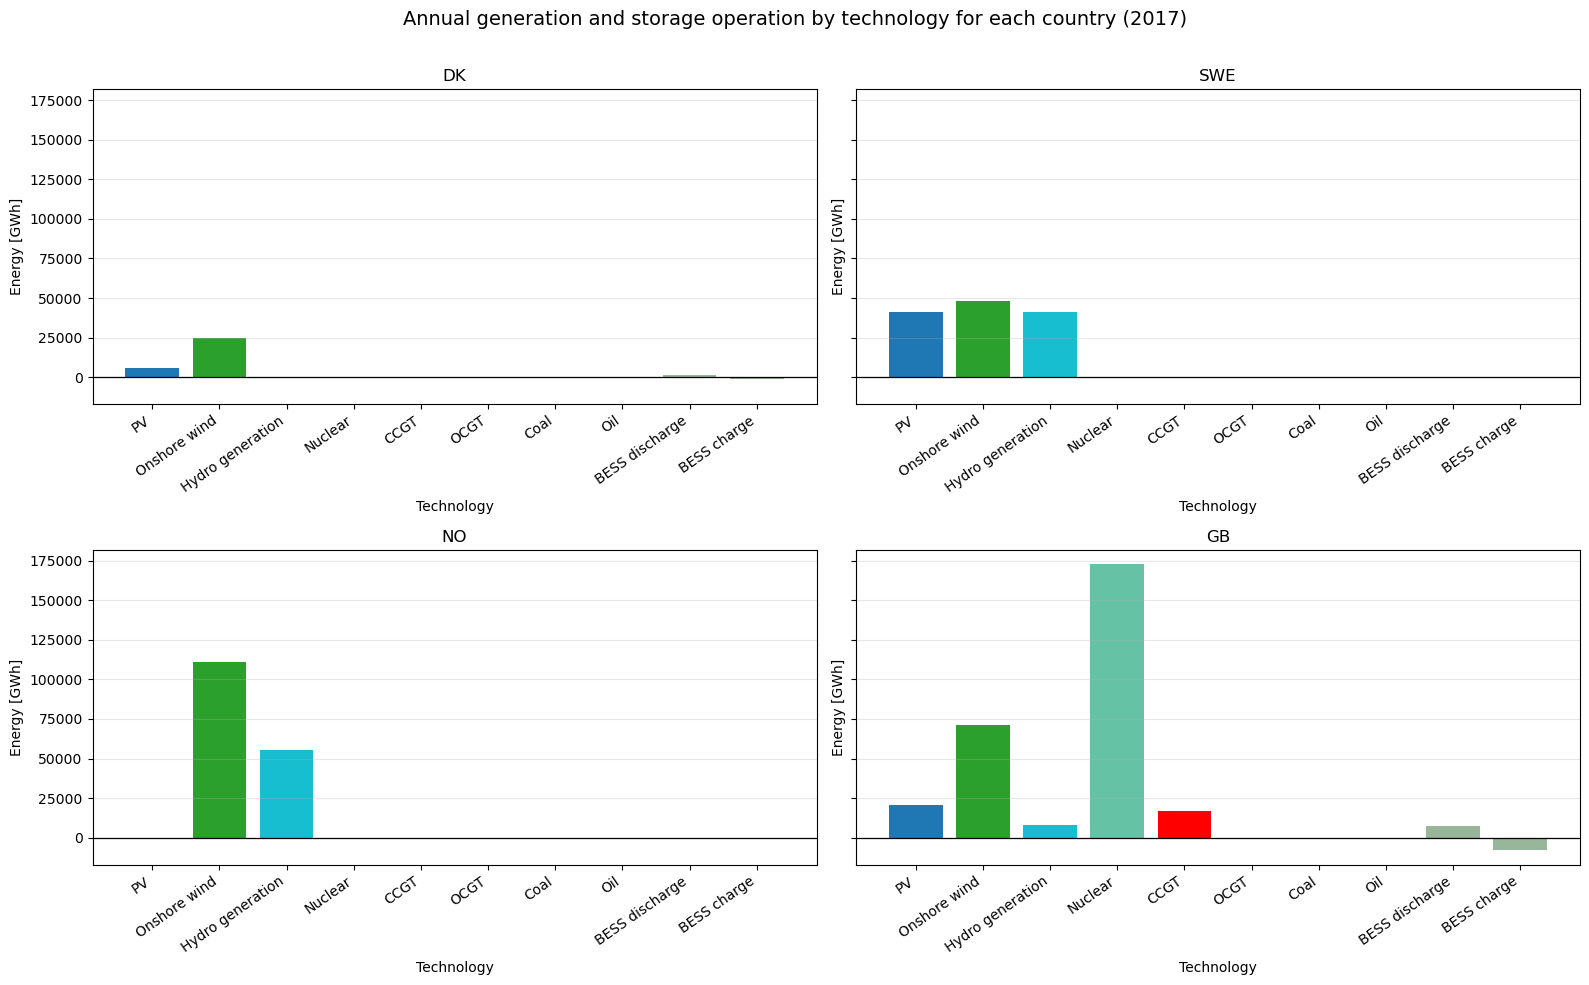

In [186]:
import matplotlib.pyplot as plt
import numpy as np

# Use your table from before:
# rows = countries, columns = technologies, values = GWh
plot_df = country_energy_table.copy()

# Optional: choose consistent technology order
desired_order = [
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Hydro generation",
    "Nuclear",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
    "Biomass CHP",
    "BESS discharge",
    "BESS charge",
]
plot_df = plot_df.reindex(columns=[c for c in desired_order if c in plot_df.columns])

# Optional: consistent colors by technology
plot_colors = {
    "PV": "#1f77b4",
    "Onshore wind": "#2ca02c",
    "Offshore wind": "orange",
    "CCGT": "red",
    "OCGT": "brown",
    "Coal": "purple",
    "Biomass CHP": "pink",
    "Oil": "gray",
    "Nuclear": "#66c2a5",
    "Hydro generation": "#17becf",
    "BESS discharge": "#1b5e20",
    "BESS charge": "#1b5e20",
}

countries = plot_df.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    values = plot_df.loc[country]
    colors = [plot_colors.get(tech, "lightgray") for tech in values.index]
    alphas = [0.45 if "charge" in tech.lower() else 1.0 for tech in values.index]

    bars = ax.bar(values.index, values.values, color=colors)

    # Apply alpha individually so BESS charge can be lighter
    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_title(country)
    ax.set_ylabel("Energy [GWh]")
    ax.set_xlabel("Technology")
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)

# Hide unused axes if fewer than 4 countries
for ax in axes[len(countries):]:
    ax.set_visible(False)

fig.suptitle(f"Annual generation and storage operation by technology for each country ({capacity_factor_year})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# PART E

In [197]:
first_snapshot = n.snapshots[0]
print(first_snapshot)
line_flows_t0 = n.lines_t.p0.loc[first_snapshot]

2017-01-01 00:00:00


In [198]:
line_flows_t0

name
DK-SWE    2415.00000
SWE-NO   -3438.45587
NO-DK     1023.45587
DK-GB     1400.00000
Name: 2017-01-01 00:00:00, dtype: float64

In [205]:
import numpy as np

B = np.array([
    [20, -10, 0],
    [-10, 20, 0],
    [0, 0, 10]
])

Binv = np.linalg.inv(B)

Bf = np.array([
    [-10, 0, 0],
    [10, -10 ,0],
    [0, 10, 0],
    [ 0, 0, -10]
])

result = np.linalg.matmul(Bf, Binv)
result

array([[-0.66666667, -0.33333333,  0.        ],
       [ 0.33333333, -0.33333333,  0.        ],
       [ 0.33333333,  0.66666667,  0.        ],
       [ 0.        ,  0.        , -1.        ]])